VISUALIZACION

In [ ]:
using Agents
using Random
using CairoMakie
#using GeometryBasics

struct HexagonalGridSpace <: Agents.AbstractSpace
    dims::Tuple{Int, Int}
    agent_positions::Dict{Tuple{Int, Int}, Vector{Int}}
    honey::Dict{Tuple{Int, Int}, Float64} 
end

function HexagonalGridSpace(dims::Tuple{Int, Int})
    positions = Dict{Tuple{Int, Int}, Vector{Int}}()
    honey = Dict{Tuple{Int, Int}, Float64}()
    for q in 1:dims[1], r in 1:dims[2]
        positions[(q, r)] = Int[]
        honey[(q, r)] = 0.0 # Inicializamos todas las celdas vacías de miel
    end
    return HexagonalGridSpace(dims, positions, honey)
end

function Agents.random_position(model::ABM{<:HexagonalGridSpace})
    q = rand(abmrng(model), 1:abmspace(model).dims[1])
    r = rand(abmrng(model), 1:abmspace(model).dims[2])
    return (q, r)
end

function Agents.add_agent_to_space!(agent, model::ABM{<:HexagonalGridSpace})
    push!(abmspace(model).agent_positions[agent.pos], agent.id)
    return agent
end

function Agents.remove_agent_from_space!(agent, model::ABM{<:HexagonalGridSpace})
    filter!(id -> id != agent.id, abmspace(model).agent_positions[agent.pos])
    return agent
end

function Agents.nearby_positions(pos::Tuple{Int, Int}, model::ABM{<:HexagonalGridSpace}, r=1)
    row, col = pos
    if row % 2 == 0
        directions = [(-1, -1), (-1, 0), (0, -1), (0, 1), (1, -1), (1, 0)]
    else
        directions = [(-1, 0), (-1, 1), (0, -1), (0, 1), (1, 0), (1, 1)]
    end

    valid_positions = Tuple{Int, Int}[]
    for (dq, dr) in directions
        new_row, new_col = row + dq, col + dr
        if 1 <= new_row <= abmspace(model).dims[1] && 1 <= new_col <= abmspace(model).dims[2]
            push!(valid_positions, (new_row, new_col))
        end
    end
    return valid_positions
end

function Agents.nearby_ids(pos::Tuple{Int, Int}, model::ABM{<:HexagonalGridSpace}, r::Int=1)
    positions_to_check = [pos; Agents.nearby_positions(pos, model, r)]
    ids = Int[]
    for p in positions_to_check
        append!(ids, abmspace(model).agent_positions[p])
    end
    return ids
end

@agent struct Bee(GridAgent{2})
end

function bee_step!(bee::Bee, model)
    vecinos = nearby_positions(bee.pos, model)
    if !isempty(vecinos)
        nueva_pos = rand(abmrng(model), vecinos)
        move_agent!(bee, nueva_pos, model)
    end
    
    abmspace(model).honey[bee.pos] += 0.5
end

function initialize_hive(; dims=(12, 14), num_bees=25, seed=42)
    space = HexagonalGridSpace(dims)
    model = StandardABM(Bee, space; agent_step! = bee_step!, rng=MersenneTwister(seed))
    for _ in 1:num_bees
        add_agent!(model)
    end
    return model
end



initialize_hive (generic function with 1 method)

In [ ]:
const HEX_SIZE = 1.0

function hex_to_pixel(row::Int, col::Int, size::Float64=HEX_SIZE)
    offset = (row % 2 == 1) ? 0.5 : 0.0
    x = size * sqrt(3) * (col - 1 + offset)
    y = size * 1.5     * (row - 1)
    return Point2f(x, y)
end

function hex_corners(center::Point2f, size::Float64=HEX_SIZE; gap::Float64=0.96)
    [center + Point2f(size * gap * cos(π/6 + π/3 * i),
                      size * gap * sin(π/6 + π/3 * i)) for i in 0:5]
end

const ABMPlot = Agents.get_ABMPlot_type()

Agents.agents_space_dimensionality(space::HexagonalGridSpace) = 2

function Agents.get_axis_limits(model::ABM{<:HexagonalGridSpace})
    rows, cols = abmspace(model).dims
    s = Float64(HEX_SIZE)
    m = s * 1.2
    xmin = 0.0 - m
    xmax = s * sqrt(3) * (cols - 0.5) + m
    ymin = 0.0 - m
    ymax = s * 1.5 * (rows - 1) + m
    return (xmin, ymin), (xmax, ymax) 
end

function Agents.agentsplot!(ax, p::ABMPlot)
    model_obs = p.abmobs[].model
    pos = @lift [hex_to_pixel(a.pos[1], a.pos[2]) for a in allagents($model_obs)]

    scatter!(ax, pos;
             color       = :black,
             markersize  = 16,
             marker      = :hexagon, 
             strokecolor = :white, # Borde blanco
             strokewidth = 1)
end

function Agents.spaceplot!(ax, p::ABMPlot; spaceplotkwargs...)
    model_obs = p.abmobs[].model
    dims      = abmspace(model_obs[]).dims

    for row in 1:dims[1], col in 1:dims[2]
        center  = hex_to_pixel(row, col)
        corners = hex_corners(center)

        cell_color = @lift begin
            miel = abmspace($model_obs).honey[(row, col)]
            
            if miel > 0
                intensidad = clamp(miel / 15.0, 0.0, 1.0)
                return RGBAf(1.0, 1.0 - 0.2*intensidad, 0.8 - 0.8*intensidad, 1.0)
            else
                return :white 
            end
        end

        poly!(ax, corners;
              color       = cell_color,
              strokecolor = :darkgrey,
              strokewidth = 1.5)
    end
end

function Agents.convert_element_pos(::HexagonalGridSpace, pos)
    row, col = pos
    return hex_to_pixel(row, col)
end

function Agents.ids_to_inspect(model::ABM{<:HexagonalGridSpace}, pos)
    return abmspace(model).agent_positions[pos]
end

function hexagon_points(radius=1.0)
    return [Point2f(radius*cos(θ), radius*sin(θ)) for θ in range(0, 2π, length=7)[1:end-1]]
end

const hexagon_polygon = Makie.Polygon(hexagon_points())
model = initialize_hive(dims=(12, 14), num_bees=25)

println("Vídeo guardado")

✓ Vídeo guardado: colmena.mp4


┌ Info: Checking for methods that have to be defined to plot an ABM with custom space type S <: HexagonalGridSpace.
│ === Required
│ ✔	agents_space_dimensionality(space::HexagonalGridSpace)
│ ✔	get_axis_limits(model::ABM{S})
│ ✔	agentsplot!(ax, p::ABMPlot)
│ === Preplots (optional)
│ ✔	spaceplot!(ax, p::ABMPlot; spaceplotkwargs...)
│ ✔	static_preplot!(ax, p::ABMPlot)
│ === Lifting (optional)
│ ✔	abmplot_heatobs(model::ABM{S}, heatarray)
│ ✔	abmplot_pos(model::ABM{S}, offset)
│ ✔	abmplot_colors(model::ABM{S}, ac)
│ ✔	abmplot_marker(model::ABM{S}, am, pos)
│ ✔	abmplot_markersizes(model::ABM{HexagonalGridSpace}, as)
│ === Inspection (optional)
│ ✔	convert_element_pos(::S, pos)
│ ✔	ids_to_inspect(model::ABM{S}, pos)
└ 12/12 checks were successful.


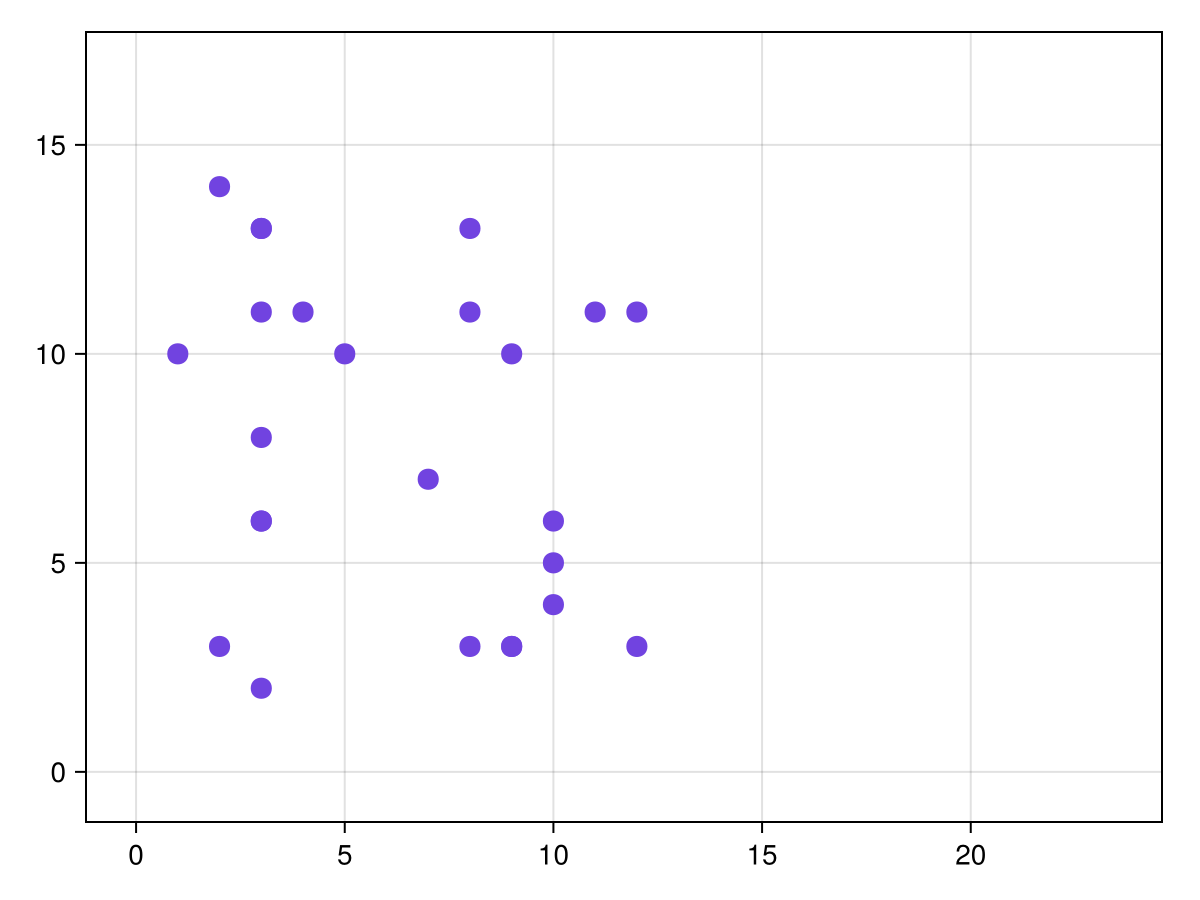

In [6]:
figure, = abmplot(model; agent_marker = hexagon_points)
figure

┌ Info: Checking for methods that have to be defined to plot an ABM with custom space type S <: HexagonalGridSpace.
│ === Required
│ ✔	agents_space_dimensionality(space::HexagonalGridSpace)
│ ✔	get_axis_limits(model::ABM{S})
│ ✔	agentsplot!(ax, p::ABMPlot)
│ === Preplots (optional)
│ ✔	spaceplot!(ax, p::ABMPlot; spaceplotkwargs...)
│ ✔	static_preplot!(ax, p::ABMPlot)
│ === Lifting (optional)
│ ✔	abmplot_heatobs(model::ABM{S}, heatarray)
│ ✔	abmplot_pos(model::ABM{S}, offset)
│ ✔	abmplot_colors(model::ABM{S}, ac)
│ ✔	abmplot_marker(model::ABM{S}, am, pos)
│ ✔	abmplot_markersizes(model::ABM{HexagonalGridSpace}, as)
│ === Inspection (optional)
│ ✔	convert_element_pos(::S, pos)
│ ✔	ids_to_inspect(model::ABM{S}, pos)
└ 12/12 checks were successful.


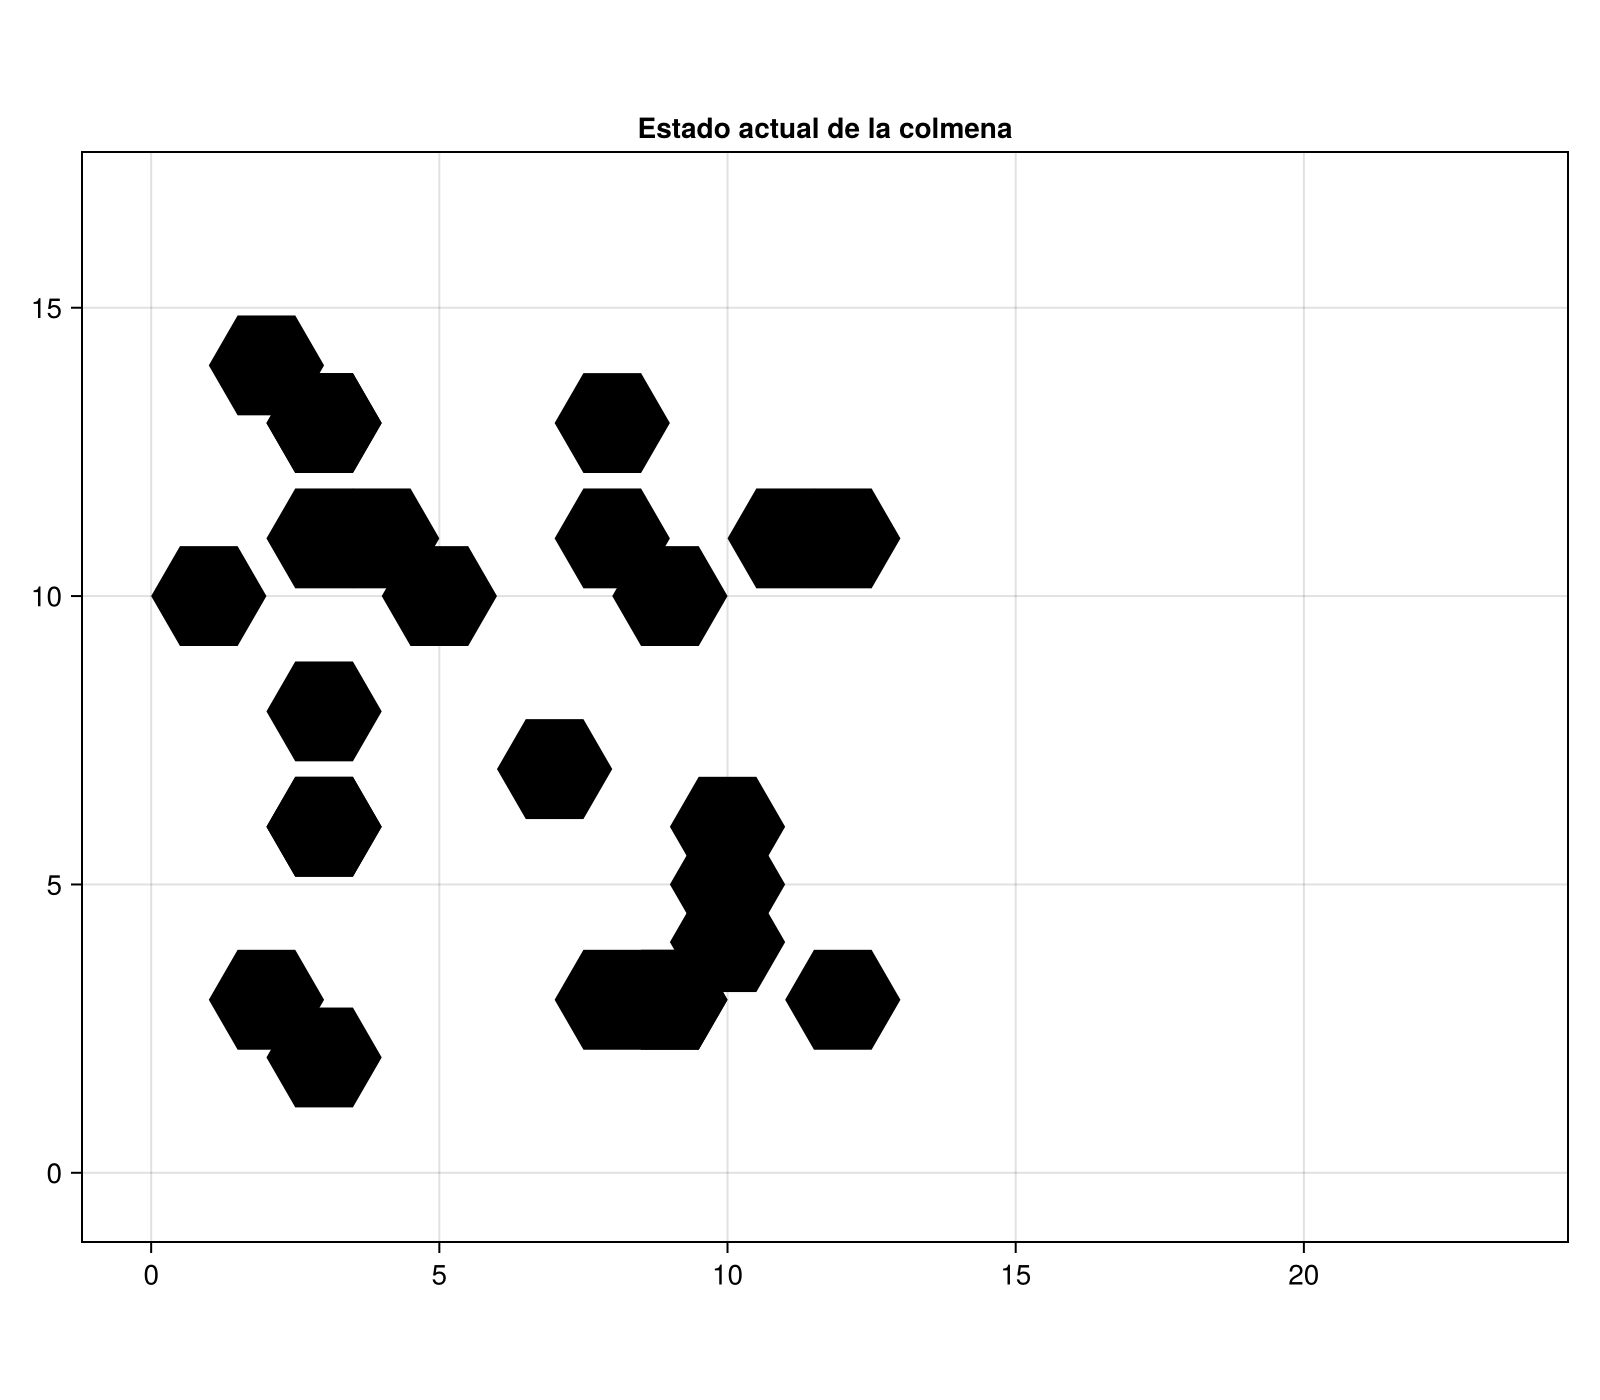

In [ ]:
const bee_hexagon = Makie.Polygon(Point2f[(cos(a), sin(a)) for a in range(0, 2π, length=7)[1:end-1]])

fig, ax, abmp = abmplot(
    model;
    #agent_pos = bee_pos,
    agent_color = _ -> :black,
    agent_marker = _ -> bee_hexagon,
    agent_size = _ -> 15,
    #static_preplot = draw_hive_background
    axis = (aspect = DataAspect(), title = "Estado actual de la colmena"),
    figure = (size=(800, 700), backgroundcolor = :white)
)

fig

In [1]:
using Agents
using Random
using CairoMakie

struct HexagonalGridSpace <: Agents.AbstractSpace
    dims::Tuple{Int, Int}
    agent_positions::Dict{Tuple{Int, Int}, Vector{Int}}
    honey::Dict{Tuple{Int, Int}, Float64}
end

function HexagonalGridSpace(dims::Tuple{Int, Int})
    positions = Dict{Tuple{Int, Int}, Vector{Int}}()
    honey     = Dict{Tuple{Int, Int}, Float64}()
    for q in 1:dims[1], r in 1:dims[2]
        positions[(q, r)] = Int[]
        honey[(q, r)]     = 0.0
    end
    return HexagonalGridSpace(dims, positions, honey)
end

function Agents.random_position(model::ABM{<:HexagonalGridSpace})
    q = rand(abmrng(model), 1:abmspace(model).dims[1])
    r = rand(abmrng(model), 1:abmspace(model).dims[2])
    return (q, r)
end

function Agents.add_agent_to_space!(agent, model::ABM{<:HexagonalGridSpace})
    push!(abmspace(model).agent_positions[agent.pos], agent.id)
    return agent
end

function Agents.remove_agent_from_space!(agent, model::ABM{<:HexagonalGridSpace})
    filter!(id -> id != agent.id, abmspace(model).agent_positions[agent.pos])
    return agent
end

function Agents.nearby_positions(pos::Tuple{Int, Int}, model::ABM{<:HexagonalGridSpace}, r=1)
    row, col = pos
    if row % 2 == 0
        directions = [(-1, -1), (-1, 0), (0, -1), (0, 1), (1, -1), (1, 0)]
    else
        directions = [(-1, 0), (-1, 1), (0, -1), (0, 1), (1, 0), (1, 1)]
    end
    valid = Tuple{Int,Int}[]
    for (dq, dr) in directions
        nr, nc = row + dq, col + dr
        if 1 <= nr <= abmspace(model).dims[1] && 1 <= nc <= abmspace(model).dims[2]
            push!(valid, (nr, nc))
        end
    end
    return valid
end

function Agents.nearby_ids(pos::Tuple{Int,Int}, model::ABM{<:HexagonalGridSpace}, r::Int=1)
    ids = Int[]
    for p in [pos; Agents.nearby_positions(pos, model, r)]
        append!(ids, abmspace(model).agent_positions[p])
    end
    return ids
end

@agent struct Bee(GridAgent{2}) end

function bee_step!(bee::Bee, model)
    vecinos = nearby_positions(bee.pos, model)
    if !isempty(vecinos)
        move_agent!(bee, rand(abmrng(model), vecinos), model)
    end
    abmspace(model).honey[bee.pos] += 0.5
end

function initialize_hive(; dims=(12, 14), num_bees=25, seed=42)
    space = HexagonalGridSpace(dims)
    model = StandardABM(Bee, space; agent_step! = bee_step!, rng=MersenneTwister(seed))
    for _ in 1:num_bees
        add_agent!(model)
    end
    return model
end

const HEX_SIZE = 1.0

function hex_to_pixel(row::Int, col::Int)
    offset = (row % 2 == 1) ? 0.5 : 0.0
    x = HEX_SIZE * sqrt(3) * (col - 1 + offset)
    y = HEX_SIZE * 1.5     * (row - 1)
    return Point2f(x, y)
end

function hex_corners(center::Point2f; gap=0.97)
    [center + Point2f(HEX_SIZE * gap * cos(π/6 + π/3*i),
                      HEX_SIZE * gap * sin(π/6 + π/3*i)) for i in 0:5]
end

function honey_color(miel::Float64)
    miel == 0.0 && return RGBAf(1.0, 1.0, 1.0, 1.0)
    t = clamp(miel / 15.0, 0.0, 1.0)
    return RGBAf(1.0, 1.0 - 0.25*t, 0.85 - 0.85*t, 1.0)
end

function draw_model!(ax::Axis, model)
    space = abmspace(model)
    dims  = space.dims

    # Fondo: hexágonos coloreados CON MIEL
    for row in 1:dims[1], col in 1:dims[2]
        center  = hex_to_pixel(row, col)
        corners = hex_corners(center; gap=0.97)
        miel    = space.honey[(row, col)]
        poly!(ax, corners;
              color       = honey_color(miel),
              strokecolor = RGBAf(0.15, 0.15, 0.15, 1.0),
              strokewidth = 1.0)
    end

    # Abejas: hexágonos pequeños negros
    for bee in allagents(model)
        center  = hex_to_pixel(bee.pos[1], bee.pos[2])
        corners = hex_corners(center; gap=0.42) # 42% del tamaño de la celda aprox
        poly!(ax, corners;
              color       = RGBAf(0.08, 0.08, 0.08, 0.95),
              strokecolor = RGBAf(1.0, 1.0, 1.0, 0.7),
              strokewidth = 0.6)
    end
end

function plot_model(model; title="Colmena hexagonal", figsize=(820, 700))
    fig = Figure(size=figsize, backgroundcolor=:white)
    ax  = Axis(fig[1, 1];
               aspect          = DataAspect(),
               title           = title,
               titlesize       = 14,
               backgroundcolor = :white)
    hidedecorations!(ax)
    hidespines!(ax)
    draw_model!(ax, model)
    return fig
end

function record_hive(model; output="colmena.mp4", frames=80, framerate=10, spf=1)
    fig = Figure(size=(820, 700), backgroundcolor=:white)
    ax  = Axis(fig[1, 1];
               aspect          = DataAspect(),
               backgroundcolor = :white)
    hidedecorations!(ax)
    hidespines!(ax)

    dims = abmspace(model).dims
    m    = HEX_SIZE * 1.5
    xlims!(ax, -m, HEX_SIZE * sqrt(3) * (dims[2] - 0.5) + m)
    ylims!(ax, -m, HEX_SIZE * 1.5 * (dims[1] - 1) + m)

    println("Grabando $frames frames → $output ...")
    record(fig, output, 1:frames; framerate=framerate) do frame
        empty!(ax)
        ax.title = "Colmena hexagonal — paso $frame"
        draw_model!(ax, model)
        step!(model, spf)
    end
    println("Guardado: $output")
end

model = initialize_hive(dims=(12, 14), num_bees=25)

# foto frame estático
fig = plot_model(model; title="Estado inicial de la colmena")
save("colmena_frame0.png", fig)
println("Imagen guardada")

# Vídeo
record_hive(model; output="colmena.mp4", frames=80, framerate=10)

Imagen guardada
Grabando 80 frames → colmena.mp4 ...
Guardado: colmena.mp4


In [ ]:
# este no vale
abmvideo(
    "colmena2.mp4", model;
    frames      = 80,
    framerate   = 10,
    figure      = (size=(700, 600), backgroundcolor = :white), # Fondo de la imagen blanco
    axis        = (title      = "Colmena en funcionamiento",
                   titlealign = :center,
                   titlecolor = :black,
                   titlesize  = 20,
                   aspect     = DataAspect()),
    enable_space_checks = true
)